In [15]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [16]:
X, y = load_digits(return_X_y=True) # shape (1797,64)
X = X/16.0
enc = OneHotEncoder(sparse_output=False)
y_onehot = enc.fit_transform(y.reshape(-1,1))
Xtr,Xte,Ytr,Yte = train_test_split(X,y_onehot,test_size=0.2,random_state=0)
n_in, n_h, n_out = Xtr.shape[1], 128, 10
rng = np.random.default_rng(0)
W1 = rng.normal(0,0.05,(n_in,n_h))
b1 = np.zeros((1,n_h))
W2 = rng.normal(0,0.05,(n_h,n_out))
b2 = np.zeros((1,n_out))
lr=0.1
bs=64
epochs=30
l2 = 1e-4   # L2 regularization strength 

In [17]:
def relu(z): 
    return np.maximum(0,z)
    
def softmax(z):
    z = z- z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e/e.sum(axis=1,keepdims=True)
    
def acc(pred, y_true):
    return (pred.argmax(1)==y_true.argmax(1)).mean()

In [18]:
loss_history = []
for ep in range(1,epochs+1):
    perm=rng.permutation(len(Xtr))
    Xtr,Xte,Ytr,Yte = Xtr[perm], Xte, Ytr[perm], Yte
    for i in range(0,len(Xtr),bs):
        xb=Xtr[i:i+bs]
        yb=Ytr[i:i+bs]
        h = relu(xb@W1 + b1)
        logits = h@W2 + b2
        probs = softmax(logits)
        loss =-np.mean(np.sum(yb*np.log(probs+1e-9),axis=1))
        # backprop
        dlogits = (probs- yb)/len(xb)
        dW2 = h.T@dlogits
        db2 = dlogits.sum(0,keepdims=True)
        dh = dlogits@W2.T
        dh[h<=0]=0
        dW1 = xb.T@dh
        db1 = dh.sum(0,keepdims=True)
        W1-= lr*dW1
        b1-= lr*db1
        W2-= lr*dW2
        b2-= lr*db2
        
    # eval
    h = relu(Xte@W1 + b1)
    probs = softmax(h@W2 + b2)
    print(f"ep{ep:02d} loss {loss:.3f} acc {acc(probs,Yte):.3f}")
    print(f"prob{probs[0]}-------{Yte[0]}")
    loss_history.append(loss)

ep01 loss 2.189 acc 0.497
prob[0.11225141 0.09514989 0.12253517 0.11136393 0.09391637 0.09374155
 0.08428728 0.08503318 0.099197   0.10252423]-------[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
ep02 loss 1.967 acc 0.703
prob[0.09486095 0.09477897 0.14321641 0.14213519 0.07002575 0.09499756
 0.07654907 0.07715758 0.10515597 0.10112253]-------[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
ep03 loss 1.641 acc 0.717
prob[0.07990878 0.09368326 0.2012173  0.18993929 0.03932376 0.07250608
 0.0418923  0.07569316 0.10503528 0.10080079]-------[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
ep04 loss 1.328 acc 0.775
prob[0.05137233 0.06195223 0.30556707 0.22233622 0.01674415 0.06383576
 0.01838693 0.05815123 0.0841111  0.11754297]-------[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
ep05 loss 0.956 acc 0.836
prob[0.03323266 0.06235788 0.44152421 0.16922412 0.00604089 0.05836406
 0.01234975 0.0423489  0.09717709 0.07738044]-------[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
ep06 loss 0.853 acc 0.869
prob[0.01356479 0.03862356 0.47199054 0.24695435 0.00132993 0.0413558

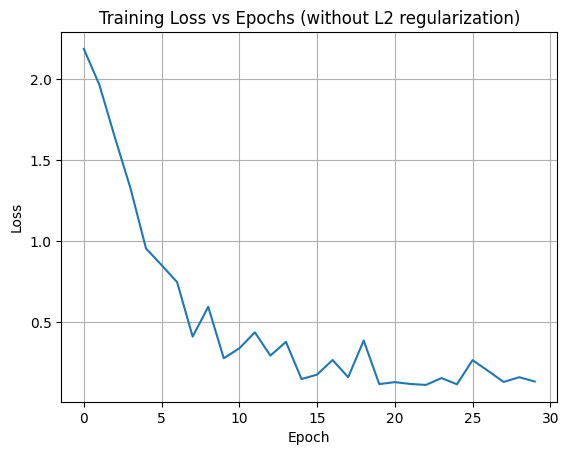

In [19]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs (without L2 regularization)")
plt.grid(True)
plt.show()

In [20]:
ht = relu(Xte@W1 + b1)
probst = softmax(ht@W2 + b2)
print(f"{probst}-------{Yte}")

[[1.32543032e-05 1.89798306e-04 9.97419210e-01 ... 1.26148952e-04
  2.45981937e-04 3.00049038e-05]
 [5.59439445e-03 1.34762674e-02 7.92666120e-03 ... 3.37175940e-03
  9.15945988e-01 1.52053475e-02]
 [1.68540419e-07 2.25541037e-04 9.98783633e-01 ... 2.42332462e-06
  5.52341291e-05 6.62980220e-07]
 ...
 [4.13598834e-05 1.39173866e-02 1.35749106e-02 ... 1.42265972e-02
  2.46695516e-01 2.60184977e-02]
 [3.29754684e-04 1.22947700e-01 2.17359633e-02 ... 8.56234655e-03
  6.80274059e-01 2.76410108e-03]
 [7.00077434e-03 3.00972398e-02 5.45357825e-04 ... 5.24284187e-03
  7.45983797e-01 1.48498615e-01]]-------[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


In [21]:
# with l2 regularization
loss_history = []
for ep in range(1,epochs+1):
    perm=rng.permutation(len(Xtr))
    Xtr,Xte,Ytr,Yte = Xtr[perm], Xte, Ytr[perm], Yte
    for i in range(0,len(Xtr),bs):
        xb=Xtr[i:i+bs]
        yb=Ytr[i:i+bs]
        h = relu(xb@W1 + b1)
        logits = h@W2 + b2
        probs = softmax(logits)
        loss =-np.mean(np.sum(yb*np.log(probs+1e-9),axis=1))
        # backprop
        dlogits = (probs- yb)/len(xb)
        dW2 = h.T@dlogits
        db2 = dlogits.sum(0,keepdims=True)
        dh = dlogits@W2.T
        dh[h<=0]=0
        dW1 = xb.T@dh
        db1 = dh.sum(0,keepdims=True)
        dW2 += l2 * W2
        dW1 += l2 * W1
        W1-= lr*dW1
        b1-= lr*db1
        W2-= lr*dW2
        b2-= lr*db2
        
    # eval
    h = relu(Xte@W1 + b1)
    probs = softmax(h@W2 + b2)
    print(f"ep{ep:02d} loss {loss:.3f} acc {acc(probs,Yte):.3f}")
    print(f"prob{probs[0]}-------{Yte[0]}")
    loss_history.append(loss)

ep01 loss 0.068 acc 0.961
prob[2.03885285e-05 1.33883199e-04 9.96947225e-01 2.18401286e-03
 1.19693288e-07 1.87124133e-05 4.59442080e-07 1.16374166e-04
 5.35396734e-04 4.34277415e-05]-------[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
ep02 loss 0.101 acc 0.958
prob[1.29212423e-05 1.44950141e-04 9.96839198e-01 2.47193969e-03
 1.19936850e-07 1.21640451e-05 3.59123538e-07 1.29248910e-04
 3.68162179e-04 2.09370343e-05]-------[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
ep03 loss 0.058 acc 0.961
prob[1.15061097e-05 1.37412633e-04 9.98701794e-01 8.31282491e-04
 8.82565630e-08 7.74856145e-06 2.53191624e-07 7.31778524e-05
 2.20077810e-04 1.66586243e-05]-------[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
ep04 loss 0.051 acc 0.961
prob[1.20663517e-05 1.00198733e-04 9.98276264e-01 1.31204664e-03
 7.34372049e-08 1.17275417e-05 2.24170718e-07 7.72174390e-05
 1.89662706e-04 2.05191650e-05]-------[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
ep05 loss 0.042 acc 0.964
prob[9.24688080e-06 9.80616207e-05 9.98592031e-01 1.02979680e-03
 6.99696661e-08 9.528

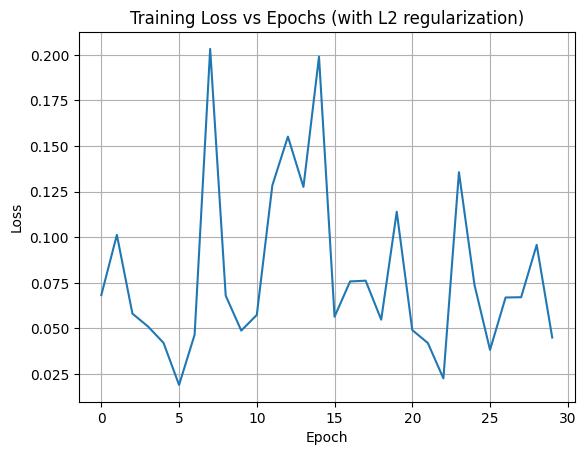

In [22]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs (with L2 regularization)")
plt.grid(True)
plt.show()

In [23]:
ht = relu(Xte@W1 + b1)
probst = softmax(ht@W2 + b2)
print(f"{probst}-------{Yte}")

[[1.75145568e-06 1.33218265e-05 9.99765379e-01 ... 1.92535149e-05
  1.19947505e-05 1.00493181e-06]
 [3.13745989e-03 3.82166068e-03 1.12010115e-03 ... 3.82836926e-04
  9.64393189e-01 3.29414611e-03]
 [6.04392736e-09 1.68153646e-05 9.99894507e-01 ... 1.86397133e-07
  2.09112835e-06 1.32766126e-08]
 ...
 [4.39247977e-06 1.04518485e-03 1.83409936e-03 ... 1.70853970e-03
  1.20446591e-01 1.10011032e-02]
 [5.57859593e-05 5.65182239e-02 8.98200107e-03 ... 2.24955262e-03
  6.40850496e-01 9.53930354e-04]
 [2.45676589e-03 3.22294098e-03 3.49123042e-05 ... 7.04059999e-04
  9.18780315e-01 4.93930147e-02]]-------[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]]
